# 07 — Volatility-Scaled Historical VaR (Filtered Historical Simulation)

**Lesson:** Decay weighting fixes the ordering problem (recent > old). But it doesn't fix the magnitude problem — a −10% COVID return at 5% daily vol overstates what a bad day looks like at 1% vol. Volatility scaling adjusts historical returns to reflect current volatility while preserving their relative extremeness.

The method makes a strong assumption: that the *shape* of the return distribution is stable — only the *width* changes. This notebook tests that assumption empirically.

**Question:** *can we use all 252 days of history without dragging stale magnitudes into today's VaR?*

## Parameters

In [1]:
# Parameters
TICKER = "SPY"
START_DATE = "2018-01-01"
END_DATE = None
VAR_WINDOW = 252
VOL_WINDOW = 20          # days for trailing realised vol
CONFIDENCE = 0.95

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.historical_var import historical_var
from src.rolling import rolling_var, rolling_decay_var
from yfinance_helpers import download_close_prices, prepare_returns

%matplotlib inline
plt.rcParams["figure.facecolor"] = "white"

In [3]:
prices = download_close_prices(TICKER, start=START_DATE, end=END_DATE)
daily_returns = prepare_returns(prices)

Prepared 2147 daily returns (2018-01-03 to 2026-07-21) from 2148 price observations.


---

## Part A: Why magnitudes matter

March 2021 — a year after the crash. The market has calmed significantly, but March 2020 crash returns are still inside the 252-day window (just barely, as the oldest returns).

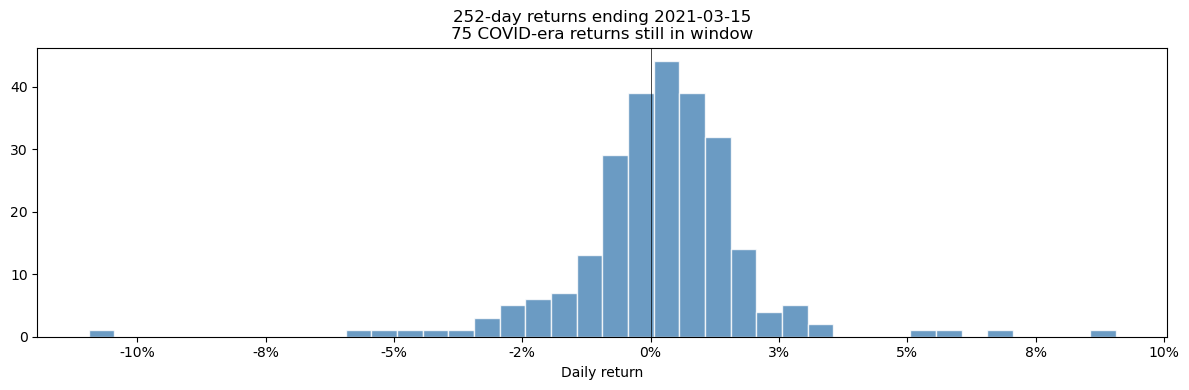

Current daily vol: 1.749%
COVID returns in window: 75, vol: 2.802%
Vol ratio (COVID / current): 1.6x
Equal-weighted 95% VaR: 2.492%


In [4]:
example_date = pd.Timestamp("2021-03-15")
example_window = daily_returns.loc[:example_date].iloc[-252:]

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(example_window, bins=40, edgecolor="white", alpha=0.8, color="steelblue")
ax.axvline(0, color="black", linewidth=0.5)

covid_mask = example_window.index <= pd.Timestamp("2020-06-30")
covid_count = covid_mask.sum()
ax.set_title(f"252-day returns ending {example_date.date()}\n{covid_count} COVID-era returns still in window")
ax.set_xlabel("Daily return")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

current_vol = example_window.std()
covid_vol = example_window[covid_mask].std()
print(f"Current daily vol: {current_vol:.3%}")
print(f"COVID returns in window: {covid_count}, vol: {covid_vol:.3%}")
print(f"Vol ratio (COVID / current): {covid_vol / current_vol:.1f}x")
print(f"Equal-weighted 95% VaR: {historical_var(example_window, confidence=0.95):.3%}")

A year after COVID, most of the market has recovered. But the equal-weighted window drags in crash-day magnitudes from March 2020 — returns of −5% to −10% when today's typical day is ±1%.

---

## Part B: How vol scaling works

### The three assumptions

1. **Shape stability:** Standardised returns ($r_t / \sigma_t$) have a stable distribution — fat tails, skew, and kurtosis are constant. Only $\sigma$ changes.
2. **Vol is correctly estimated:** The trailing realised vol ($\sigma_t$) accurately reflects the vol at each point in time.
3. **The sample contains tail events:** The window must contain some extreme standardised returns to scale up. Vol scaling can rescale events but cannot invent them.

### The scaling formula

$$r_t^{\text{scaled}} = r_t \times \frac{\sigma_{\text{today}}}{\sigma_t}$$

In [5]:
# Walkthrough: scale a single day's window
walkthrough_date = pd.Timestamp("2021-03-15")
walkthrough_window = daily_returns.loc[:walkthrough_date].iloc[-VAR_WINDOW:]

trailing_vol = daily_returns.rolling(window=VOL_WINDOW).std().clip(lower=0.001)
vol_today = trailing_vol.loc[walkthrough_window.index[-1]]
vol_at_each_return = trailing_vol.loc[walkthrough_window.index]
scaled_returns = walkthrough_window * (vol_today / vol_at_each_return)

print(f"sigma_today (Mar 2021): {vol_today:.4%}")
print(f"Min sigma_t in window:     {vol_at_each_return.min():.4%}")
print(f"Max sigma_t in window:     {vol_at_each_return.max():.4%}")
print(f"Original 95% VaR:       {historical_var(walkthrough_window, confidence=0.95):.4%}")
print(f"Vol-scaled 95% VaR:     {historical_var(scaled_returns, confidence=0.95):.4%}")

sigma_today (Mar 2021): 1.1536%
Min sigma_t in window:     0.5040%
Max sigma_t in window:     5.8701%
Original 95% VaR:       2.4921%
Vol-scaled 95% VaR:     1.5289%


### Visual: original vs standardised vs scaled returns

Same number of bins, same x-axis limits for the two return histograms — the shape comparison is proportional. The standardised and scaled distributions have the same shape (they differ only by a constant multiplier $\sigma_{\text{today}}$). Both are narrower than the original because standardisation strips out the time-varying volatility that artificially fattened the tails.

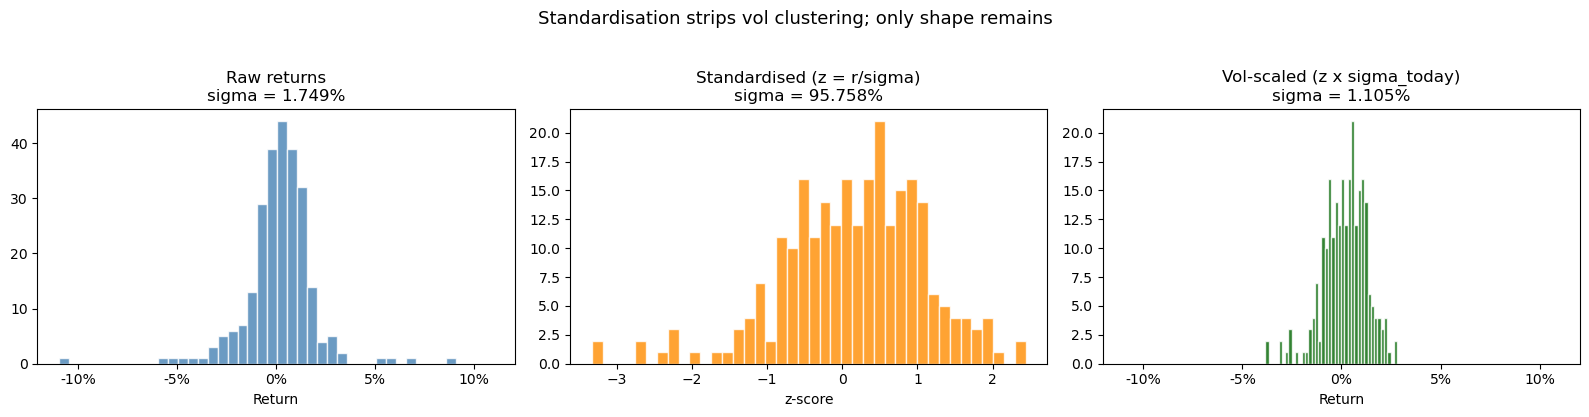

In [6]:
standardised_returns = walkthrough_window / vol_at_each_return

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
n_bins = 40
x_limit = max(abs(walkthrough_window).max(), abs(scaled_returns).max()) * 1.1

axes[0].hist(walkthrough_window, bins=n_bins, edgecolor="white", alpha=0.8, color="steelblue")
axes[0].set_title(f"Raw returns\nsigma = {walkthrough_window.std():.3%}")
axes[0].set_xlabel("Return")
axes[0].set_xlim(-x_limit, x_limit)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

axes[1].hist(standardised_returns, bins=n_bins, edgecolor="white", alpha=0.8, color="darkorange")
axes[1].set_title(f"Standardised (z = r/sigma)\nsigma = {standardised_returns.std():.3%}")
axes[1].set_xlabel("z-score")

axes[2].hist(scaled_returns, bins=n_bins, edgecolor="white", alpha=0.8, color="darkgreen")
axes[2].set_title(f"Vol-scaled (z x sigma_today)\nsigma = {scaled_returns.std():.3%}")
axes[2].set_xlabel("Return")
axes[2].set_xlim(-x_limit, x_limit)
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.suptitle("Standardisation strips vol clustering; only shape remains", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

---

## Part C: Vol-scaled VaR on SPY

Now compute rolling vol-scaled VaR across the full sample.

In [7]:
trailing_vol = daily_returns.rolling(window=VOL_WINDOW).std().clip(lower=0.001)

first_estimable = VAR_WINDOW + VOL_WINDOW
print(f"Computing rolling vol-scaled VaR (starting from day {first_estimable})...")

vol_scaled_var_list = []
vol_scaled_next_list = []
vol_scaled_breach_list = []
vol_scaled_date_list = []

for day in range(first_estimable, len(daily_returns)):
    window_returns = daily_returns.iloc[day - VAR_WINDOW : day]
    window_index = window_returns.index
    vol_current = trailing_vol.loc[window_index[-1]]
    vol_at_each = trailing_vol.loc[window_index].values
    if np.isnan(vol_at_each).any():
        continue
    scaled = window_returns.values * (vol_current / vol_at_each)
    var_estimate = historical_var(scaled, confidence=CONFIDENCE)
    next_return = daily_returns.iloc[day]
    vol_scaled_var_list.append(var_estimate)
    vol_scaled_next_list.append(next_return)
    vol_scaled_breach_list.append(-next_return > var_estimate)
    vol_scaled_date_list.append(daily_returns.index[day])

vol_scaled_result = pd.DataFrame(
    {"VaR": vol_scaled_var_list, "NextReturn": vol_scaled_next_list, "Breach": vol_scaled_breach_list},
    index=pd.DatetimeIndex(vol_scaled_date_list, name="Date"))

print(f"Done: {len(vol_scaled_result)} estimates "
      f"({vol_scaled_result.index[0].date()} to {vol_scaled_result.index[-1].date()})")

Computing rolling vol-scaled VaR (starting from day 272)...


Done: 1875 estimates (2019-02-04 to 2026-07-21)


### Compare with equal-weighted and decay-weighted

In [8]:
equal_result = rolling_var(daily_returns, window=VAR_WINDOW, confidence=CONFIDENCE)
decay_result = rolling_decay_var(daily_returns, window=VAR_WINDOW, lam=0.94, confidence=CONFIDENCE)

for name, result in [
    ("Equal-weighted", equal_result),
    ("Decay lam=0.94", decay_result),
    ("Vol-scaled", vol_scaled_result),
]:
    print(f"{name:<20}: {result['Breach'].sum():>4} breaches ({result['Breach'].mean():.3%})")

Equal-weighted      :   90 breaches (4.749%)
Decay lam=0.94      :  113 breaches (5.963%)
Vol-scaled          :  116 breaches (6.187%)


### Overlay: all three methods

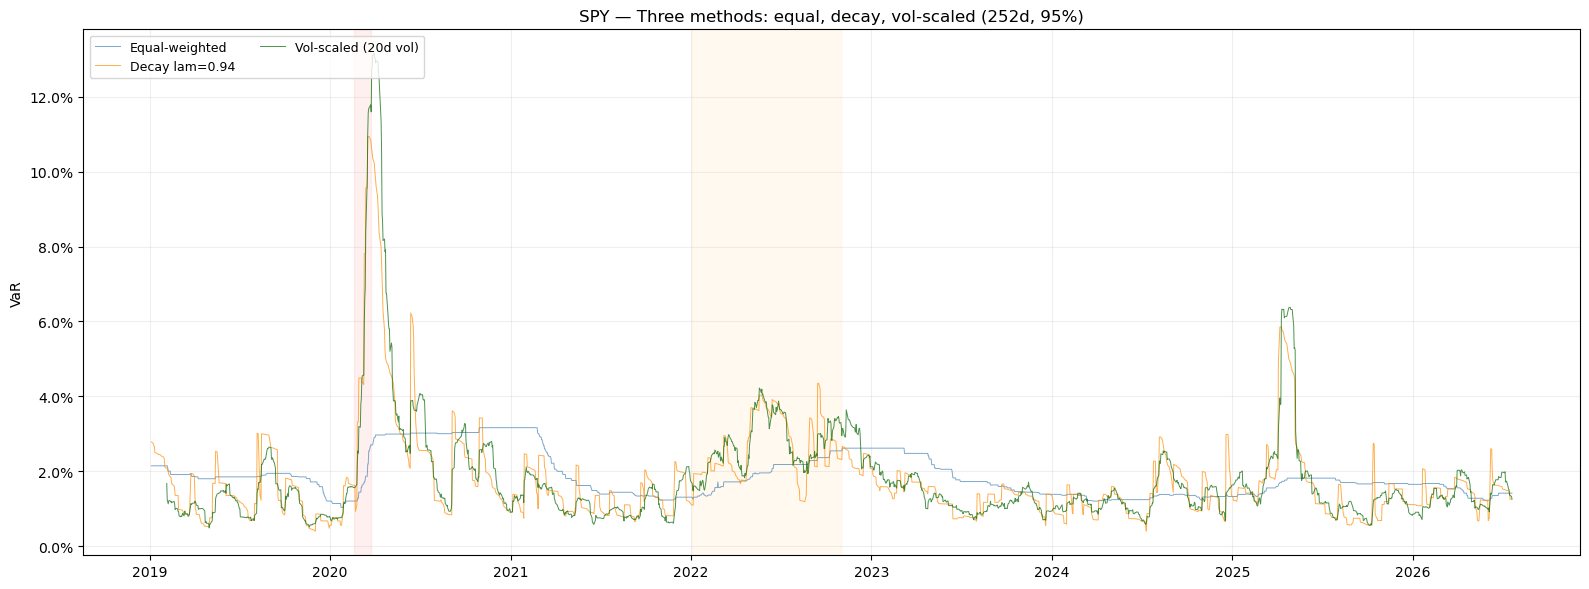

In [9]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(equal_result.index, equal_result["VaR"], linewidth=0.7, color="steelblue", alpha=0.7, label="Equal-weighted")
ax.plot(decay_result.index, decay_result["VaR"], linewidth=0.7, color="darkorange", alpha=0.7, label="Decay lam=0.94")
ax.plot(vol_scaled_result.index, vol_scaled_result["VaR"], linewidth=0.7, color="darkgreen", alpha=0.7,
        label=f"Vol-scaled ({VOL_WINDOW}d vol)")

ax.axvspan(pd.Timestamp("2020-02-19"), pd.Timestamp("2020-03-23"), alpha=0.06, color="red")
ax.axvspan(pd.Timestamp("2022-01-03"), pd.Timestamp("2022-10-31"), alpha=0.06, color="orange")

ax.set_ylabel("VaR")
ax.set_title(f"{TICKER} — Three methods: equal, decay, vol-scaled ({VAR_WINDOW}d, {CONFIDENCE:.0%})")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.legend(loc="upper left", ncol=2, fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### Zoom: COVID crash — reaction speed

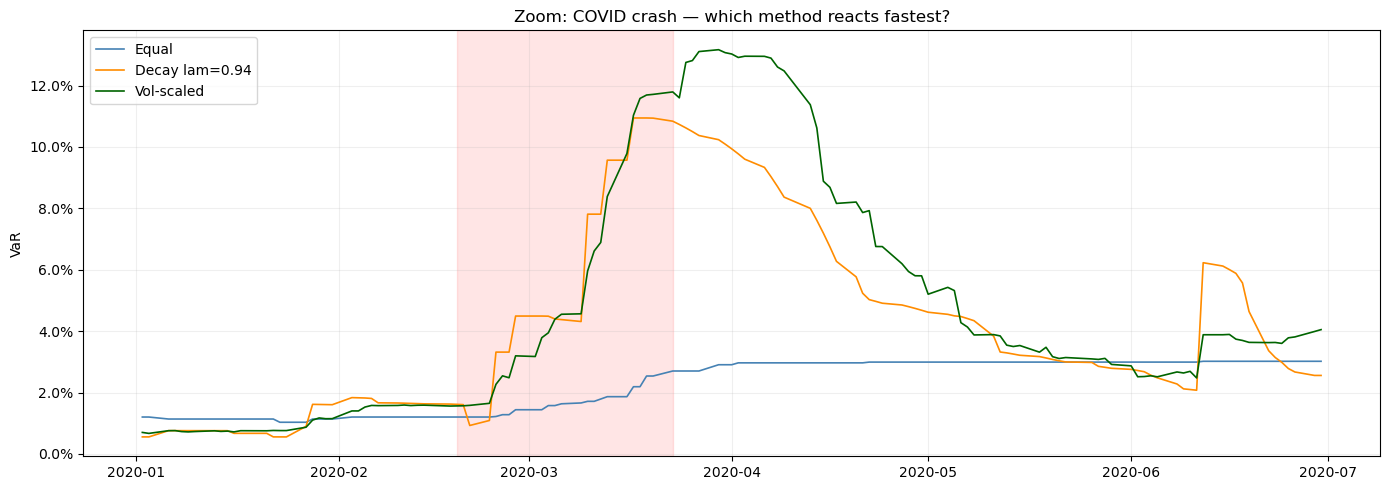

Equal-weighted      : VaR = 1.202%, doubled in 29 days
Decay lam=0.94      : VaR = 1.615%, doubled in 6 days
Vol-scaled          : VaR = 1.564%, doubled in 9 days


In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
zoom_start, zoom_end = pd.Timestamp("2020-01-02"), pd.Timestamp("2020-06-30")

for result, label, color in [
    (equal_result, "Equal", "steelblue"),
    (decay_result, "Decay lam=0.94", "darkorange"),
    (vol_scaled_result, "Vol-scaled", "darkgreen"),
]:
    in_zoom = (result.index >= zoom_start) & (result.index <= zoom_end)
    ax.plot(result.index[in_zoom], result["VaR"][in_zoom], linewidth=1.2, color=color, label=label)

ax.axvspan(pd.Timestamp("2020-02-19"), pd.Timestamp("2020-03-23"), alpha=0.1, color="red")
ax.set_ylabel("VaR")
ax.set_title("Zoom: COVID crash — which method reacts fastest?")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.legend(loc="upper left")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

crash_start = pd.Timestamp("2020-02-19")
for name, result in [
    ("Equal-weighted", equal_result),
    ("Decay lam=0.94", decay_result),
    ("Vol-scaled", vol_scaled_result),
]:
    pre_crash_var = result.loc[:crash_start, "VaR"].iloc[-1]
    after_crash = result.loc[crash_start:]
    doubled = after_crash[after_crash["VaR"] > pre_crash_var * 2]
    if len(doubled) > 0:
        days_to_double = (doubled.index[0] - crash_start).days
        print(f"{name:<20}: VaR = {pre_crash_var:.3%}, doubled in {days_to_double} days")

---

## Part D: Three-method comparison

Regime-conditional breach rates — which model is most consistent?

In [11]:
regime_periods = {
    "Pre-COVID (2018-Feb 2020)": (equal_result.index < "2020-02-19"),
    "COVID crash (Feb-Jun 2020)": (
        (equal_result.index >= "2020-02-19") & (equal_result.index <= "2020-06-30")
    ),
    "Post-COVID (Jul 2020+)": (equal_result.index >= "2020-07-01"),
}

print(f"{'Regime':<32} {'Equal':>8} {'Decay':>8} {'Vol-Sc':>8} {'Target':>8}")
print("-" * 70)
for regime_name, mask in regime_periods.items():
    equal_rate = equal_result[mask]["Breach"].mean()
    decay_rate = decay_result[mask]["Breach"].mean()
    common_dates = vol_scaled_result.index.isin(equal_result[mask].index)
    vol_scaled_rate = vol_scaled_result.loc[common_dates, "Breach"].mean()
    print(f"{regime_name:<32} {equal_rate:>7.2%} {decay_rate:>7.2%} {vol_scaled_rate:>7.2%} {1-CONFIDENCE:>7.2%}")

Regime                              Equal    Decay   Vol-Sc   Target
----------------------------------------------------------------------
Pre-COVID (2018-Feb 2020)          2.48%   5.32%   7.25%   5.00%
COVID crash (Feb-Jun 2020)        17.20%   7.53%   7.53%   5.00%
Post-COVID (Jul 2020+)             4.41%   5.99%   5.92%   5.00%


---

## Part E: Testing the shape-stability assumption

This is the core test. Vol scaling assumes standardised returns have the same distribution regardless of regime.

In [12]:
standardised_returns = daily_returns / trailing_vol

pre_covid_std = standardised_returns[:"2020-02-19"].dropna()
covid_std = standardised_returns["2020-02-19":"2020-06-30"].dropna()
post_covid_std = standardised_returns["2020-07-01":].dropna()

print(f"{'Regime':<28} {'Obs':>6} {'Mean':>7} {'Std':>7} {'Skew':>8} {'Ex Kurt':>9}")
print("-" * 70)
for regime_name, data in [
    ("Pre-COVID", pre_covid_std),
    ("COVID", covid_std),
    ("Post-COVID", post_covid_std),
]:
    print(f"{regime_name:<28} {len(data):>6} {data.mean():>6.3f} {data.std():>6.3f} "
          f"{data.skew():>7.2f} {data.kurtosis():>8.2f}")

Regime                          Obs    Mean     Std     Skew   Ex Kurt
----------------------------------------------------------------------
Pre-COVID                       516  0.073  1.032   -0.56     0.83
COVID                            93 -0.047  1.136   -0.66     0.61
Post-COVID                     1520  0.084  1.007   -0.35     0.40


### What to look for
- **Skew:** More negative during crises → left tail fatter even after standardising → assumption violated
- **Excess kurtosis:** Higher during crises → more extreme events → assumption violated
- **Std:** Should be ~1.0. >1 during crises → vol estimate was too low

### QQ plot: pre-COVID vs COVID standardised returns

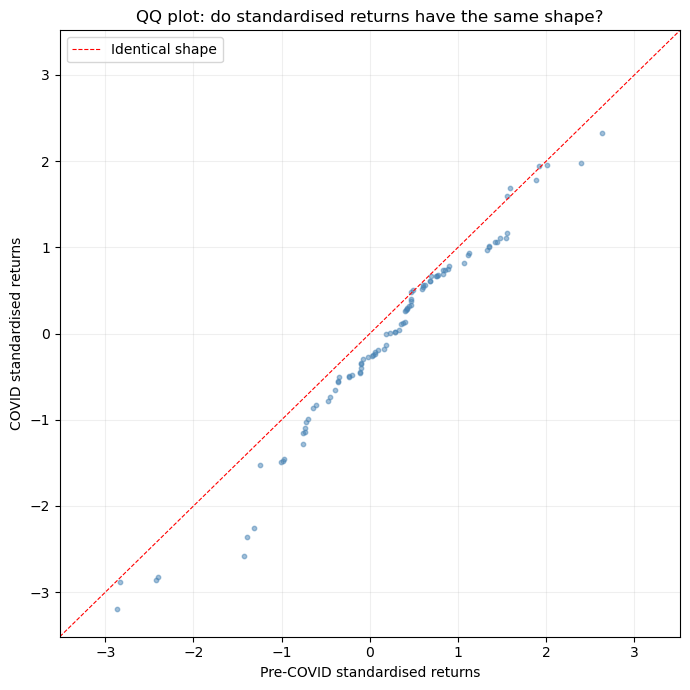

In [13]:
fig, ax = plt.subplots(figsize=(7, 7))
sample_size = min(len(pre_covid_std), len(covid_std))
pre_quantiles = np.sort(pre_covid_std.sample(n=sample_size, random_state=42))
covid_quantiles = np.sort(covid_std.sample(n=sample_size, random_state=42))

ax.scatter(pre_quantiles, covid_quantiles, alpha=0.5, s=10, color="steelblue")
axis_limit = max(abs(pre_quantiles).max(), abs(covid_quantiles).max()) * 1.1
ax.plot([-axis_limit, axis_limit], [-axis_limit, axis_limit], "r--", linewidth=0.8, label="Identical shape")
ax.set_xlabel("Pre-COVID standardised returns")
ax.set_ylabel("COVID standardised returns")
ax.set_title("QQ plot: do standardised returns have the same shape?")
ax.set_xlim(-axis_limit, axis_limit)
ax.set_ylim(-axis_limit, axis_limit)
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### KS test

In [14]:
ks_statistic, ks_pvalue = stats.ks_2samp(pre_covid_std, covid_std)
print(f"KS statistic: {ks_statistic:.4f}, p-value: {ks_pvalue:.4f}")
if ks_pvalue < 0.05:
    print("Distributions are significantly different. Shape-stability assumption REJECTED.")
else:
    print("Cannot reject same distribution. Shape-stability assumption not rejected.")

KS statistic: 0.0862, p-value: 0.5679
Cannot reject same distribution. Shape-stability assumption not rejected.


---

## Part F: Vol window sensitivity

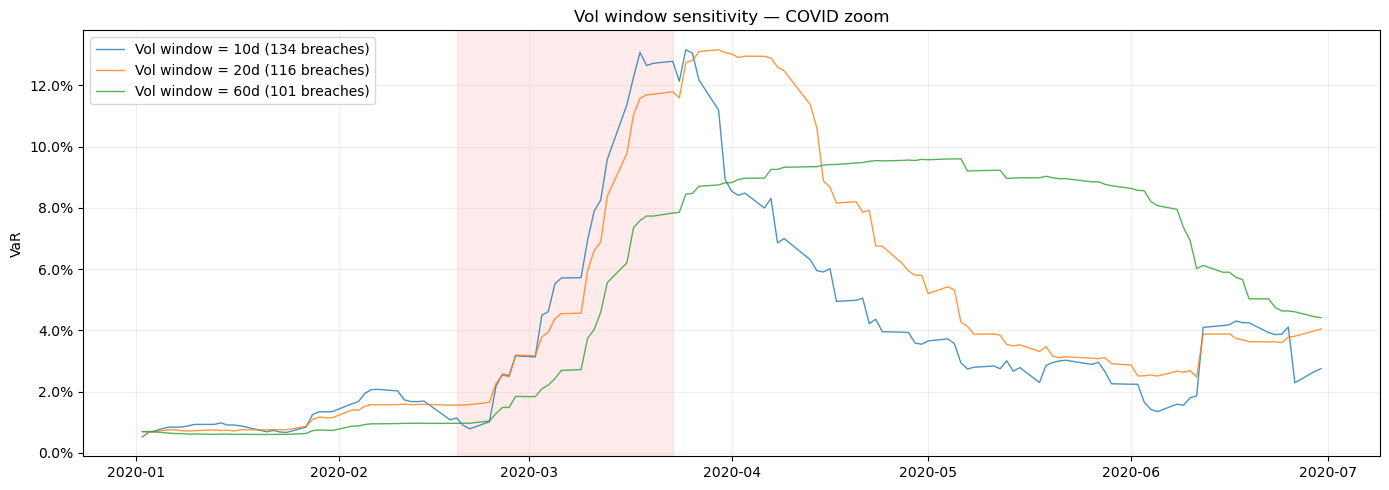

In [15]:
vol_window_sizes = [10, 20, 60]
results_by_vol_window = {}
zoom_start, zoom_end = pd.Timestamp("2020-01-02"), pd.Timestamp("2020-06-30")

fig, ax = plt.subplots(figsize=(14, 5))

for vol_window_size in vol_window_sizes:
    trailing_vol_vw = daily_returns.rolling(window=vol_window_size).std().clip(lower=0.001)
    var_list, next_list, breach_list, date_list = [], [], [], []
    estimable_from = VAR_WINDOW + vol_window_size
    for day in range(estimable_from, len(daily_returns)):
        window_returns = daily_returns.iloc[day - VAR_WINDOW : day]
        window_index = window_returns.index
        vol_current = trailing_vol_vw.loc[window_index[-1]]
        vol_at_each = trailing_vol_vw.loc[window_index].values
        if np.isnan(vol_at_each).any():
            continue
        scaled = window_returns.values * (vol_current / vol_at_each)
        var_estimate = historical_var(scaled, confidence=CONFIDENCE)
        var_list.append(var_estimate)
        next_list.append(daily_returns.iloc[day])
        breach_list.append(-daily_returns.iloc[day] > var_estimate)
        date_list.append(daily_returns.index[day])
    df = pd.DataFrame({"VaR": var_list, "NextReturn": next_list, "Breach": breach_list},
                      index=pd.DatetimeIndex(date_list, name="Date"))
    results_by_vol_window[vol_window_size] = df
    in_zoom = (df.index >= zoom_start) & (df.index <= zoom_end)
    ax.plot(df.index[in_zoom], df["VaR"][in_zoom], linewidth=1.0, alpha=0.8,
            label=f"Vol window = {vol_window_size}d ({df['Breach'].sum()} breaches)")

ax.axvspan(pd.Timestamp("2020-02-19"), pd.Timestamp("2020-03-23"), alpha=0.08, color="red")
ax.set_ylabel("VaR")
ax.set_title("Vol window sensitivity — COVID zoom")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.legend(loc="upper left")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---

## Part G: Limitations summary

What vol scaling does and doesn't address.

In [16]:
limitations = pd.DataFrame({
    "Limitation": [
        "Regime-change lag (slow ordering update)",
        "Stale return magnitudes",
        "Shape shifts during crises",
        "No tail events in window",
        "Correlation breakdown (portfolio)",
        "Vol estimation error",
        "Parameter proliferation",
    ],
    "Fixed by vol scaling?": [
        "No — still uses fixed window. Combine with decay.",
        "Yes — this is the main fix.",
        "No — core assumption violation. Crisis tails are fatter.",
        "No — can't invent events, only rescale existing ones.",
        "No — vol scaling is per-asset only.",
        "Partially — only as good as the vol estimate.",
        "Worse — adds a parameter on top of existing ones.",
    ],
})
display(limitations.style.hide(axis="index"))

Limitation,Fixed by vol scaling?
Regime-change lag (slow ordering update),No — still uses fixed window. Combine with decay.
Stale return magnitudes,Yes — this is the main fix.
Shape shifts during crises,No — core assumption violation. Crisis tails are fatter.
No tail events in window,"No — can't invent events, only rescale existing ones."
Correlation breakdown (portfolio),No — vol scaling is per-asset only.
Vol estimation error,Partially — only as good as the vol estimate.
Parameter proliferation,Worse — adds a parameter on top of existing ones.


---

## Key insight

Volatility scaling is the most sophisticated of the three mitigations, but it makes the strongest assumption: shape stability.

The meta-lesson across all three methods:

| Method | Replaces this | With this (weaker) assumption |
|--------|-------------|-------------------------------|
| Equal-weighted | Returns are stationary | — |
| Decay-weighted | All days equally relevant | Recent days matter more |
| Vol-scaled | Return magnitudes stable | Standardised return shape stable |

None eliminate assumptions — they make them more defensible and testable. The right approach is to use all three as a dashboard and monitor where they disagree.